# Sentinel-1 Analysis (S1 + S2 Relationship)

This notebook analyzes:
- Temporal behavior of Sentinel-1 metrics by year/quarter
- Coverage of S1 vs S2
- Relationship between S1 backscatter features and S2 indices

Data source: `data/ghana_parquet_s1` (partitioned by `year=`).


In [6]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
BASE = DATA_DIR / 'ghana_parquet_s1'

if not BASE.exists():
    raise FileNotFoundError(f'Missing dataset: {BASE}')

print('Dataset:', BASE)


Dataset: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana_parquet_s1


In [7]:
# Load partitioned parquet robustly (handles metadata/schema variation)
needed = [
    'osm_id', 'fclass', 'year', 'quarter',
    'NDVI', 'NDMI', 'NDBI', 'NDWI', 'BSI',
    's1_vv_mean', 's1_vh_mean', 's1_vv_minus_vh_mean',
    's1_vv_std', 's1_vh_std', 's1_vv_minus_vh_std'
]

frames = []
year_dirs = sorted([p for p in BASE.glob('year=*') if p.is_dir()])

for yp in year_dirs:
    m = re.search(r'year=(\d{4})', yp.name)
    y = int(m.group(1)) if m else None

    for f in sorted(yp.glob('*.parquet')):
        t = pq.read_table(f)
        d = t.to_pandas(ignore_metadata=True)
        if 'year' not in d.columns and y is not None:
            d['year'] = y

        # align schema; missing columns become NA
        d = d.reindex(columns=needed)
        frames.append(d)

if not frames:
    raise RuntimeError(f'No parquet fragments found under {BASE}')

df = pd.concat(frames, ignore_index=True)

# Normalize types
for c in ['osm_id', 'fclass', 'quarter']:
    df[c] = df[c].astype('string')
df['osm_id'] = df['osm_id'].str.strip()
df['fclass'] = df['fclass'].str.strip().str.lower()
df['quarter'] = df['quarter'].str.upper().str.extract(r'(Q[1-4])', expand=False)
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

num_cols = [c for c in needed if c.startswith('s1_') or c in ['NDVI','NDMI','NDBI','NDWI','BSI']]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# key dedupe safety
key = ['osm_id', 'fclass', 'year', 'quarter']
df = df.dropna(subset=['osm_id', 'year', 'quarter'])
df = df[df['osm_id'] != '']
df = df.drop_duplicates(subset=key, keep='last')

print('Rows:', len(df))
print('Years:', sorted(df['year'].dropna().unique().tolist()))
print('Quarters:', sorted(df['quarter'].dropna().unique().tolist()))
print('Columns:', df.columns.tolist())


Rows: 10433892
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Quarters: ['Q1', 'Q2', 'Q3', 'Q4']
Columns: ['osm_id', 'fclass', 'year', 'quarter', 'NDVI', 'NDMI', 'NDBI', 'NDWI', 'BSI', 's1_vv_mean', 's1_vh_mean', 's1_vv_minus_vh_mean', 's1_vv_std', 's1_vh_std', 's1_vv_minus_vh_std']


In [9]:
# Coverage diagnostics: where do we have S1 and S2?
s1_cols = [c for c in df.columns if c.startswith('s1_')]
s2_cols = ['NDVI', 'NDMI', 'NDBI', 'NDWI', 'BSI']

has_s1 = df[s1_cols].notna().any(axis=1)
has_s2 = df[s2_cols].notna().any(axis=1)

coverage = pd.DataFrame({
    "has_s1": has_s1,
    "has_s2": has_s2,
    "year": df["year"],
    "quarter": df["quarter"],
})
coverage["both"] = coverage["has_s1"] & coverage["has_s2"]

by_yq = (
    coverage.groupby(["year", "quarter"], dropna=False)
    .agg(
        rows=("has_s1", "size"),
        s1_rows=("has_s1", "sum"),
        s2_rows=("has_s2", "sum"),
        both_rows=("both", "sum"),
    )
    .reset_index()
)

by_yq["s1_pct"] = by_yq["s1_rows"] / by_yq["rows"]
by_yq["s2_pct"] = by_yq["s2_rows"] / by_yq["rows"]

display(by_yq.sort_values(["year", "quarter"]))

,year,quarter,rows,s1_rows,s2_rows,both_rows,s1_pct,s2_pct
0,2017,Q1,372639,371800,69790,69790,0.997748,0.187286
1,2017,Q2,372639,371800,0,0,0.997748,0.000000
2,2017,Q3,372639,371800,0,0,0.997748,0.000000
3,2017,Q4,372639,371800,146876,146876,0.997748,0.394151
4,2018,Q1,372639,371800,196133,196133,0.997748,0.526335
5,2018,Q2,372639,371800,455,455,0.997748,0.001221
6,2018,Q3,372639,371800,0,0,0.997748,0.000000
7,2018,Q4,372639,371800,326546,326546,0.997748,0.876307
8,2019,Q1,372639,371800,326546,326546,0.997748,0.876307
9,2019,Q2,372639,371800,281559,281559,0.997748,0.755581


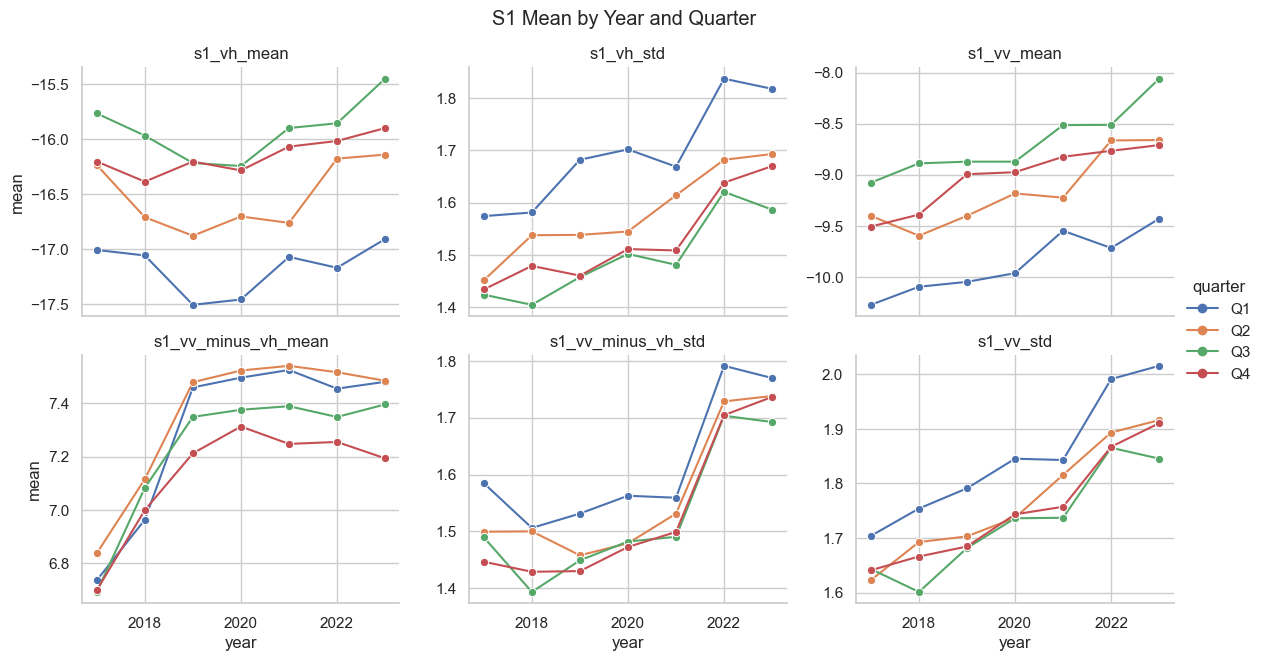

In [10]:
# 1) S1 temporal trends by year-quarter
if s1_cols:
    long_s1 = (
        df.melt(
            id_vars=['year','quarter'],
            value_vars=s1_cols,
            var_name='metric',
            value_name='value'
        )
        .dropna(subset=['year','quarter','value'])
    )

    trend = (
        long_s1.groupby(['year','quarter','metric'], as_index=False)
        .agg(mean=('value','mean'), median=('value','median'))
    )

    g = sns.relplot(
        data=trend,
        x='year', y='mean',
        col='metric', col_wrap=3,
        hue='quarter', marker='o', kind='line',
        facet_kws={'sharey': False},
        height=3.2, aspect=1.25
    )
    g.set_titles('{col_name}')
    g.fig.suptitle('S1 Mean by Year and Quarter', y=1.03)
    plt.show()
else:
    print('No S1 columns found')


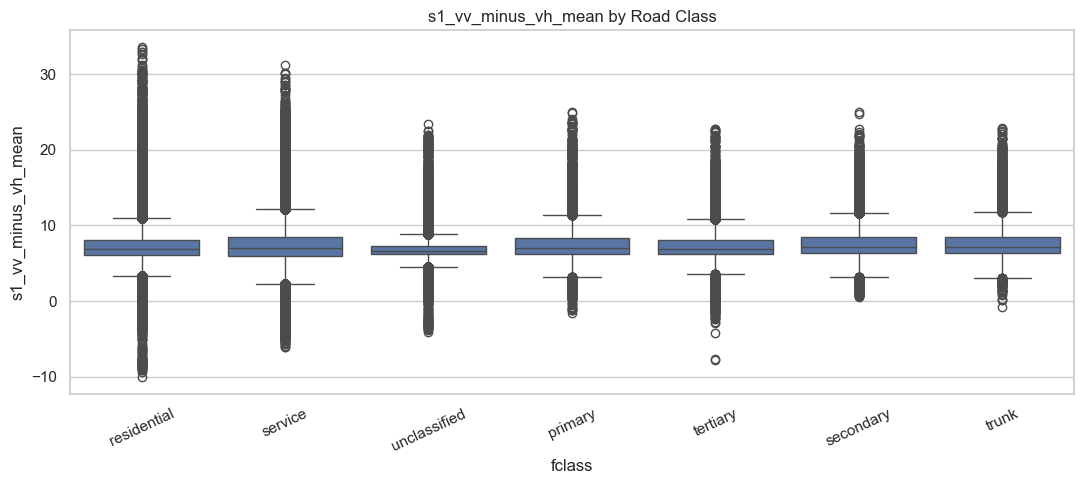

In [11]:
# 2) S1 distribution by road class (top classes)
if s1_cols and 'fclass' in df.columns:
    top_classes = df['fclass'].value_counts(dropna=True).head(7).index.tolist()
    sub = df[df['fclass'].isin(top_classes)].copy()

    plot_metric = 's1_vv_minus_vh_mean' if 's1_vv_minus_vh_mean' in s1_cols else s1_cols[0]
    sub = sub.dropna(subset=[plot_metric, 'fclass'])

    plt.figure(figsize=(11, 5))
    sns.boxplot(data=sub, x='fclass', y=plot_metric)
    plt.title(f'{plot_metric} by Road Class')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
else:
    print('Missing S1 columns or fclass')


,scope,year,s1,s2,corr,n
10,overall,NaN,s1_vv_minus_vh_mean,NDVI,-0.254127,6375404
25,overall,NaN,s1_vv_minus_vh_std,NDVI,-0.248024,6375404
9,overall,NaN,s1_vh_mean,BSI,-0.219786,6375404
15,overall,NaN,s1_vv_std,NDVI,-0.210929,6375404
26,overall,NaN,s1_vv_minus_vh_std,NDMI,-0.206865,6375404
7,overall,NaN,s1_vh_mean,NDBI,-0.199628,6375404
20,overall,NaN,s1_vh_std,NDVI,-0.198180,6375404
11,overall,NaN,s1_vv_minus_vh_mean,NDMI,-0.195311,6375404
21,overall,NaN,s1_vh_std,NDMI,-0.189103,6375404
16,overall,NaN,s1_vv_std,NDMI,-0.171099,6375404


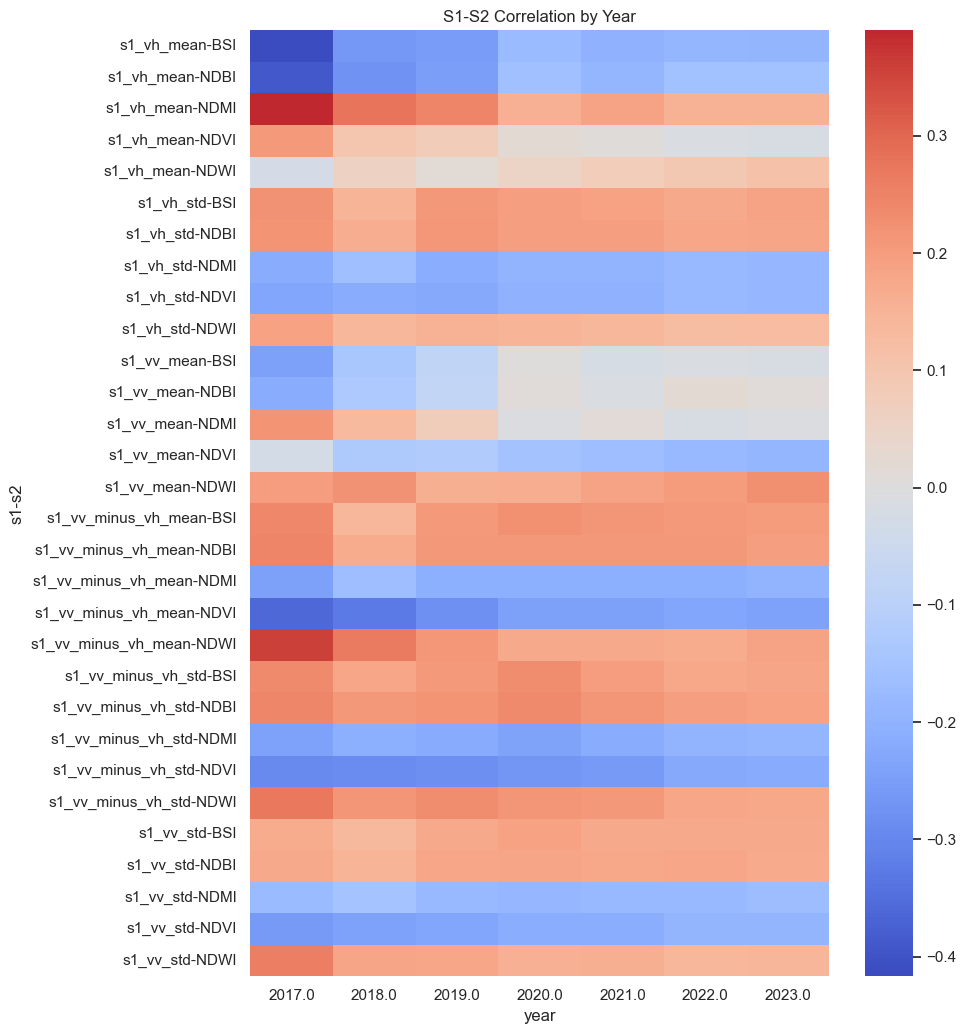

In [13]:
# 3) Relationship: S1 vs S2 correlations (overall and by year)
pairs = []
for s1 in s1_cols:
    for s2 in s2_cols:
        if s2 in df.columns:
            pairs.append((s1, s2))

corr_rows = []
for a, b in pairs:
    d = df[[a, b]].dropna()
    if len(d) >= 100:
        corr_rows.append({'scope':'overall', 'year':None, 's1':a, 's2':b, 'corr':d[a].corr(d[b]), 'n':len(d)})

for y, gdf in df.groupby('year'):
    for a, b in pairs:
        d = gdf[[a, b]].dropna()
        if len(d) >= 100:
            corr_rows.append({'scope':'year', 'year':int(y), 's1':a, 's2':b, 'corr':d[a].corr(d[b]), 'n':len(d)})

corr_df = pd.DataFrame(corr_rows)
if corr_df.empty:
    print('Not enough overlapping S1-S2 rows for correlation analysis.')
else:
    display(corr_df[corr_df['scope']=='overall'].sort_values('corr'))

    year_corr = corr_df[corr_df['scope']=='year'].copy()
    if not year_corr.empty:
        heat = year_corr.pivot_table(index=['s1','s2'], columns='year', values='corr')
        plt.figure(figsize=(10, max(4, 0.35 * len(heat))))
        sns.heatmap(heat, cmap='coolwarm', center=0, annot=False)
        plt.title('S1-S2 Correlation by Year')
        plt.tight_layout()
        plt.show()


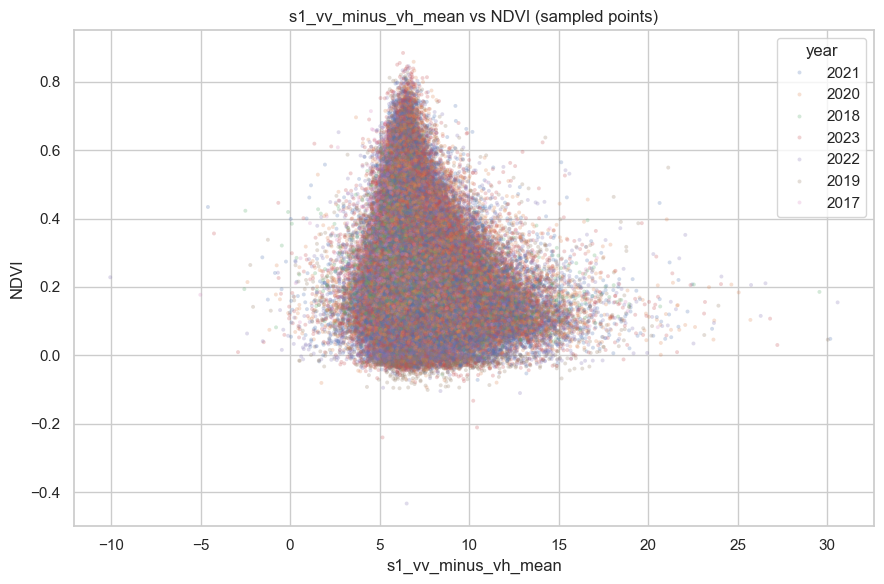

In [15]:
# 4) Visual scatter: sample only for speed/readability
# (Aggregations above are full-data. This sample is only for point plots.)
sample_n = min(300_000, len(df))
plot_df = df.sample(sample_n, random_state=42) if len(df) > sample_n else df.copy()

x_col = 's1_vv_minus_vh_mean' if 's1_vv_minus_vh_mean' in s1_cols else (s1_cols[0] if s1_cols else None)
y_col = 'NDVI' if 'NDVI' in df.columns else None

if x_col and y_col:
    d = plot_df[[x_col, y_col, 'year']].dropna().copy()
    d['year'] = d['year'].astype(int).astype(str)

    if len(d) > 0:
        plt.figure(figsize=(9,6))
        sns.scatterplot(data=d, x=x_col, y=y_col, hue='year', alpha=0.25, s=8, linewidth=0)
        plt.title(f'{x_col} vs {y_col} (sampled points)')
        plt.tight_layout()
        plt.show()
    else:
        print('No overlapping non-null values for scatter plot.')
else:
    print('Required columns for scatter not found.')


## Notes
- `S1-only` rows indicate places/times where Sentinel-1 exists but S2 indices are missing.
- Correlation is association, not causation.
- If you want stricter comparability, subset to a single quarter (e.g., `Q1`) before correlation.


## Paved vs Unpaved (from OSM PBF)

This section maps `osm_id` to `surface` from `ghana-260415.osm.pbf`, then compares S1/S2 metrics for paved vs unpaved roads.


In [16]:
# Build paved/unpaved lookup from OSM PBF (ways)
import pyrosm

PBF_PATH = DATA_DIR / 'ghana-260415.osm.pbf'
if not PBF_PATH.exists():
    raise FileNotFoundError(f'Missing PBF: {PBF_PATH}')

osm = pyrosm.OSM(str(PBF_PATH))
roads = osm.get_network(network_type='driving', extra_attributes=['surface'])

if roads is None or roads.empty:
    raise RuntimeError('No driving roads extracted from PBF')

# Normalize id and surface
roads = roads[['id', 'surface']].copy()
roads = roads.rename(columns={'id': 'osm_id'})
roads['osm_id'] = roads['osm_id'].astype('string').str.strip()
roads['surface'] = roads['surface'].astype('string').str.strip().str.lower()

paved_vals = {
    'asphalt', 'concrete', 'paved', 'paving_stones', 'sett',
    'concrete:lanes', 'concrete:plates', 'metal', 'wood'
}
unpaved_vals = {
    'unpaved', 'gravel', 'dirt', 'ground', 'earth', 'sand',
    'mud', 'grass', 'compacted', 'fine_gravel', 'pebblestone', 'clay'
}

def classify_surface(s):
    if pd.isna(s):
        return pd.NA
    s = str(s).strip().lower()
    if s in paved_vals:
        return 'paved'
    if s in unpaved_vals:
        return 'unpaved'
    # common mixed/other explicit labels
    if any(k in s for k in ['asphalt', 'concrete', 'paved']):
        return 'paved'
    if any(k in s for k in ['gravel', 'dirt', 'earth', 'ground', 'sand', 'mud', 'unpaved']):
        return 'unpaved'
    return pd.NA

roads['surface_class'] = roads['surface'].map(classify_surface)
lookup = roads[['osm_id', 'surface', 'surface_class']].drop_duplicates(subset=['osm_id'], keep='first')

print('Road rows extracted:', len(roads))
print('Unique osm_id in lookup:', lookup['osm_id'].nunique())
print('Surface class counts:')
print(lookup['surface_class'].value_counts(dropna=False))


Road rows extracted: 331676
Unique osm_id in lookup: 331676
Surface class counts:
surface_class
<NA>       301209
unpaved     17131
paved       13336
Name: count, dtype: int64


In [17]:
# Join paved/unpaved labels to analysis dataframe
df_surface = df.merge(lookup[['osm_id', 'surface_class']], on='osm_id', how='left')

print('Rows in analysis df:', len(df_surface))
print('Rows with paved/unpaved label:', int(df_surface['surface_class'].notna().sum()))
print('Label coverage %:', round(100 * df_surface['surface_class'].notna().mean(), 2))

surface_yq = (
    df_surface.groupby(['year','quarter','surface_class'], dropna=False)
    .size()
    .rename('rows')
    .reset_index()
)
display(surface_yq.sort_values(['year','quarter','surface_class']))


Rows in analysis df: 10433892
Rows with paved/unpaved label: 847056
Label coverage %: 8.12


,year,quarter,surface_class,rows
0,2017,Q1,paved,13270
1,2017,Q1,unpaved,16982
2,2017,Q1,NaN,342387
3,2017,Q2,paved,13270
4,2017,Q2,unpaved,16982
...,...,...,...,...
79,2023,Q3,unpaved,16982
80,2023,Q3,NaN,342387
81,2023,Q4,paved,13270
82,2023,Q4,unpaved,16982


In [18]:
# Compare S1/S2 metrics for paved vs unpaved
metrics = [
    's1_vv_mean', 's1_vh_mean', 's1_vv_minus_vh_mean',
    's1_vv_std', 's1_vh_std', 's1_vv_minus_vh_std',
    'NDVI', 'NDMI', 'NDBI', 'NDWI', 'BSI'
]
metrics = [m for m in metrics if m in df_surface.columns]

comp = df_surface[df_surface['surface_class'].isin(['paved','unpaved'])].copy()

summary_rows = []
for m in metrics:
    d = comp[['surface_class', m]].dropna()
    if d.empty:
        continue
    grp = d.groupby('surface_class')[m]
    row = {
        'metric': m,
        'paved_n': int((d['surface_class'] == 'paved').sum()),
        'unpaved_n': int((d['surface_class'] == 'unpaved').sum()),
        'paved_mean': grp.mean().get('paved', pd.NA),
        'unpaved_mean': grp.mean().get('unpaved', pd.NA),
        'paved_median': grp.median().get('paved', pd.NA),
        'unpaved_median': grp.median().get('unpaved', pd.NA),
    }
    if pd.notna(row['paved_mean']) and pd.notna(row['unpaved_mean']):
        row['mean_diff_paved_minus_unpaved'] = row['paved_mean'] - row['unpaved_mean']
    else:
        row['mean_diff_paved_minus_unpaved'] = pd.NA
    summary_rows.append(row)

surface_summary = pd.DataFrame(summary_rows)
display(surface_summary.sort_values('metric'))


,metric,paved_n,unpaved_n,paved_mean,unpaved_mean,paved_median,unpaved_median,mean_diff_paved_minus_unpaved
10,BSI,255289,340533,0.119985,0.107673,0.134846,0.133214,0.012312
8,NDBI,255289,340533,0.095593,0.068214,0.113312,0.096816,0.027379
7,NDMI,255289,340533,-0.095593,-0.068214,-0.113312,-0.096816,-0.027379
6,NDVI,255289,340533,0.164273,0.284210,0.136091,0.251105,-0.119937
9,NDWI,255289,340533,-0.231838,-0.355530,-0.220974,-0.358867,0.123692
1,s1_vh_mean,368536,474740,-16.538508,-16.815922,-16.551622,-16.538604,0.277414
4,s1_vh_std,368536,474740,1.708695,1.650360,1.584912,1.486654,0.058334
0,s1_vv_mean,368536,474740,-8.919845,-9.685966,-9.241127,-9.749636,0.766121
2,s1_vv_minus_vh_mean,368536,474740,7.618663,7.129956,7.211647,6.790906,0.488707
5,s1_vv_minus_vh_std,368536,474740,1.694169,1.552143,1.575598,1.411746,0.142026


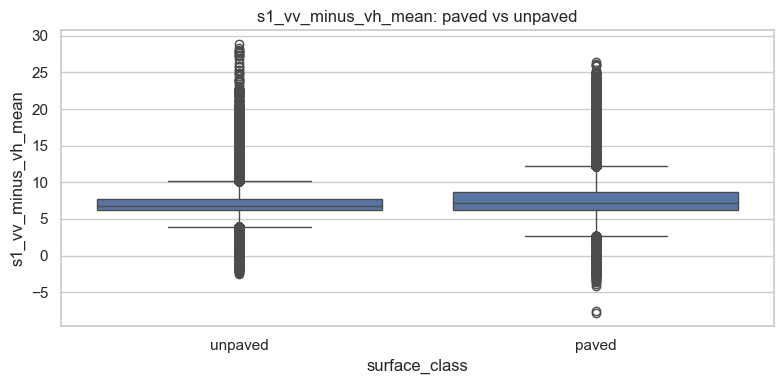

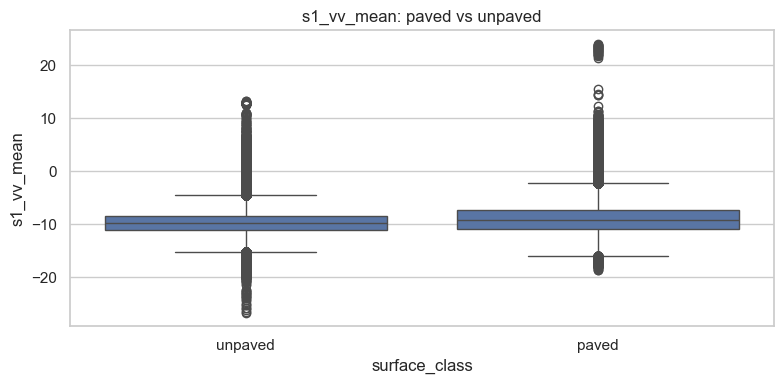

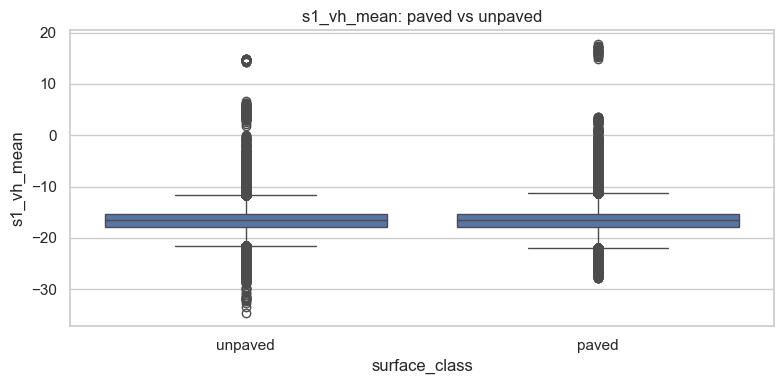

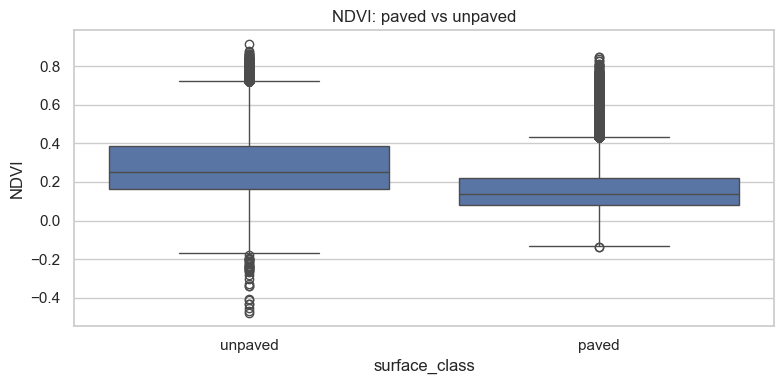

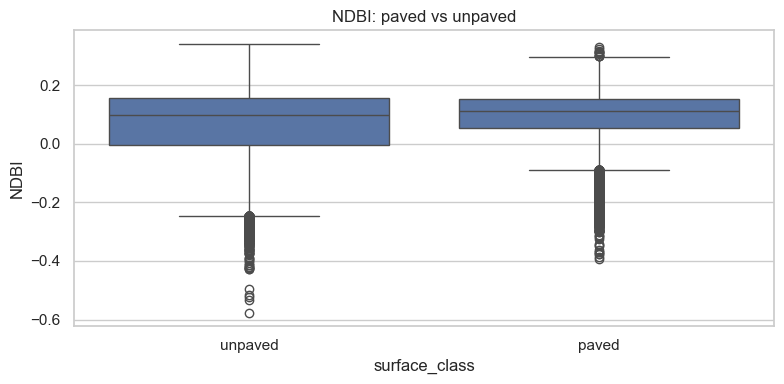

In [19]:
# Visual comparison: key metric distributions by surface class
plot_metrics = [m for m in ['s1_vv_minus_vh_mean', 's1_vv_mean', 's1_vh_mean', 'NDVI', 'NDBI'] if m in df_surface.columns]
plot_df = df_surface[df_surface['surface_class'].isin(['paved','unpaved'])].copy()

for m in plot_metrics:
    d = plot_df[['surface_class', m]].dropna()
    if d.empty:
        continue

    plt.figure(figsize=(8,4))
    sns.boxplot(data=d, x='surface_class', y=m)
    plt.title(f'{m}: paved vs unpaved')
    plt.tight_layout()
    plt.show()
